In [4]:
pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
 

In [6]:
import yfinance as yf
import pandas as pd

In [40]:
# Fetch RELIANCE stock data
stock = yf.download("RELIANCE.NS", start="2022-01-01", end="2026-04-01")

stock.reset_index(inplace=True)

# Save CSV (backup)
stock.to_csv("reliance_stock.csv", index=False)

print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price        Date        Close         High          Low         Open  \
Ticker             RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
0      2022-01-03  1093.780640  1095.646251  1075.443709  1076.103491   
1      2022-01-04  1118.464966  1119.784530  1093.848795  1099.263532   
2      2022-01-05  1123.697754  1127.064905  1107.021590  1120.239736   
3      2022-01-06  1099.536621  1116.599603  1096.123977  1115.325533   
4      2022-01-07  1108.409302  1118.442271  1097.284238  1106.111499   

Price       Volume  
Ticker RELIANCE.NS  
0          5421611  
1         10847728  
2         11643813  
3         14447422  
4         13112115  


In [42]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Moving averages
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# Returns
df['Returns'] = df['Close'].pct_change()

# Volatility
df['Volatility'] = df['Returns'].rolling(20).std()

# Signal
df['Signal'] = df['MA_50'] > df['MA_200']

df.to_csv("processed_data.csv", index=False)

print(df.tail())

           Date        Close                High                 Low  \
984  2025-12-24  1558.199951   1575.699951171875  1553.5999755859375   
985  2025-12-26  1559.199951              1561.0   1554.300048828125   
986  2025-12-29  1545.599976  1558.0999755859375  1543.5999755859375   
987  2025-12-30  1539.800049  1553.5999755859375   1537.800048828125   
988  2025-12-31  1570.400024              1577.0              1541.0   

                   Open   Volume        MA_50       MA_200   Returns  \
984   1572.699951171875  8815745  1512.538005  1412.111169 -0.007958   
985   1554.699951171875  2311495  1516.204004  1414.052552  0.000642   
986  1554.9000244140625  5972105  1519.630002  1415.756611 -0.008722   
987              1547.0  8815884  1522.460002  1417.231469 -0.003753   
988              1541.0  5771830  1525.532002  1418.916101  0.019873   

     Volatility  Signal  
984    0.006427    True  
985    0.006367    True  
986    0.006611    True  
987    0.006647    True  
988 

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("processed_data.csv")

# Create Target
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


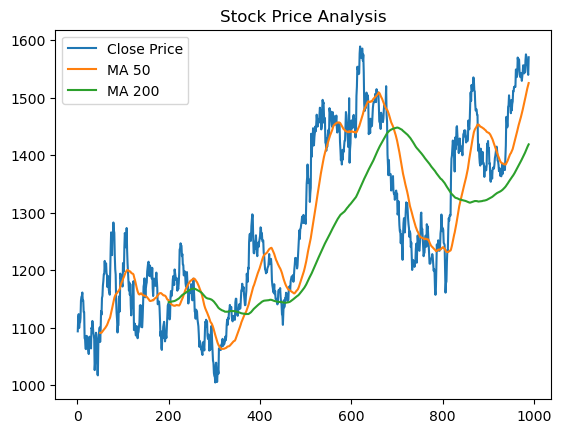

In [46]:
import matplotlib.pyplot as plt

df = pd.read_csv("processed_data.csv")

plt.figure()
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_50'], label='MA 50')
plt.plot(df['MA_200'], label='MA 200')

plt.legend()
plt.title("Stock Price Analysis")
plt.show()

In [60]:
from sklearn.ensemble import RandomForestRegressor

# Load processed data
df = pd.read_csv("processed_data.csv")

# Ensure numeric columns
cols = ['Open','High','Low','Close','Volume']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create Target
df['Target'] = df['Close'].shift(-1)

# Feature Engineering
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low_Diff'] = df['High'] - df['Low']

df.dropna(inplace=True)

# Features
features = [
    'Open','High','Low','Volume',
    'MA_50','MA_200',
    'Price_Change','High_Low_Diff'
]

X = df[features]
y = df['Target']

# Train-test split (time series)
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

print("Model trained successfully ✅")

# =========================
# 🔮 FUTURE PREDICTION (2026)
# =========================

future_days = 365
future_predictions = []

temp_df = df.copy()

for i in range(future_days):
    
    last_row = temp_df[features].tail(1)
    
    next_price = model.predict(last_row)[0]
    
    future_predictions.append(next_price)
    
    # Create next row
    new_row = temp_df.tail(1).copy()
    
    new_row['Open'] = next_price
    new_row['High'] = next_price * 1.01
    new_row['Low'] = next_price * 0.99
    new_row['Close'] = next_price
    new_row['Volume'] = new_row['Volume']  # keep same
    
    # Update features
    new_row['Price_Change'] = new_row['Close'] - new_row['Open']
    new_row['High_Low_Diff'] = new_row['High'] - new_row['Low']
    
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)
    
    # Recalculate moving averages
    temp_df['MA_50'] = temp_df['Close'].rolling(50).mean()
    temp_df['MA_200'] = temp_df['Close'].rolling(200).mean()

print("First 10 predicted prices for 2026:")
print(future_predictions[:10])

Model trained successfully ✅
First 10 predicted prices for 2026:
[1515.4201989746093, 1500.7405749511718, 1492.747333984375, 1488.4483581542968, 1489.912900390625, 1489.2988696289062, 1489.982265625, 1489.3225244140624, 1490.0059204101562, 1489.3225244140624]


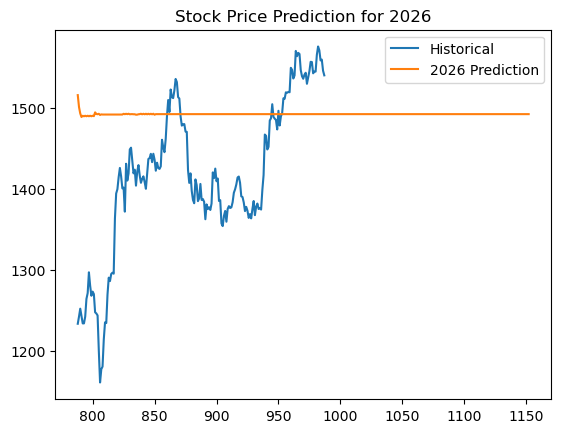

In [62]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df['Close'].tail(200), label="Historical")

plt.plot(
    range(len(df), len(df)+365),
    future_predictions,
    label="2026 Prediction"
)

plt.legend()
plt.title("Stock Price Prediction for 2026")
plt.show()